# Miniproject


In [4]:
# Libraries
import os, glob
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.io import wavfile
import heapq
from collections import Counter

### Inspecting the data

In [5]:
# Load the data
DATA_DIR = "Data"
wav_paths = sorted(glob.glob(os.path.join(DATA_DIR, "*", "*.wav")))
print(f"Found {len(wav_paths)} wav files")
for p in wav_paths:
    print(" ", p)

# Get the signals and their properties
signals = {}
for path in wav_paths:
    speaker = os.path.basename(os.path.dirname(path))     # "F1", etc.
    name    = os.path.splitext(os.path.basename(path))[0] # "SX199", etc.
    key     = f"{speaker}/{name}"
    sr, x   = wavfile.read(path)
    signals[key] = {"sr": sr, "x": x, "dtype": x.dtype,
                    "n_samples": len(x), "duration_s": len(x) / sr}
    
# Summary table
hdr = f"{'file':<14}{'sr':>7}{'samples':>10}{'dur(s)':>8}{'dtype':>8}{'min':>8}{'max':>8}"
print(hdr); print("-" * len(hdr))
for k, s in signals.items():
    print(f"{k:<14}{s['sr']:>7}{s['n_samples']:>10}{s['duration_s']:>8.2f}"
          f"{str(s['dtype']):>8}{s['x'].min():>8}{s['x'].max():>8}")

Found 16 wav files
  Data\F1\SA1.wav
  Data\F1\SI1573.wav
  Data\F2\SX304.wav
  Data\F2\SX34.wav
  Data\F3\SI2114.wav
  Data\F3\SX134.wav
  Data\F4\SI2204.wav
  Data\F4\SX224.wav
  Data\M1\SA2.wav
  Data\M1\SI2293.wav
  Data\M2\SI602.wav
  Data\M2\SX374.wav
  Data\M3\SX199.wav
  Data\M3\SX289.wav
  Data\M4\SI1019.wav
  Data\M4\SX389.wav
file               sr   samples  dur(s)   dtype     min     max
---------------------------------------------------------------
F1/SA1           8000     31744    3.97   int16  -30519   32767
F1/SI1573        8000     39783    4.97   int16  -18529   32767
F2/SX304         8000     22375    2.80   int16  -25024   32767
F2/SX34          8000     18893    2.36   int16  -21808   32767
F3/SI2114        8000     20480    2.56   int16  -22393   32767
F3/SX134         8000     22477    2.81   int16  -24370   32767
F4/SI2204        8000     30874    3.86   int16  -32767   31647
F4/SX224         8000     12903    1.61   int16  -26109   32767
M1/SA2           8000

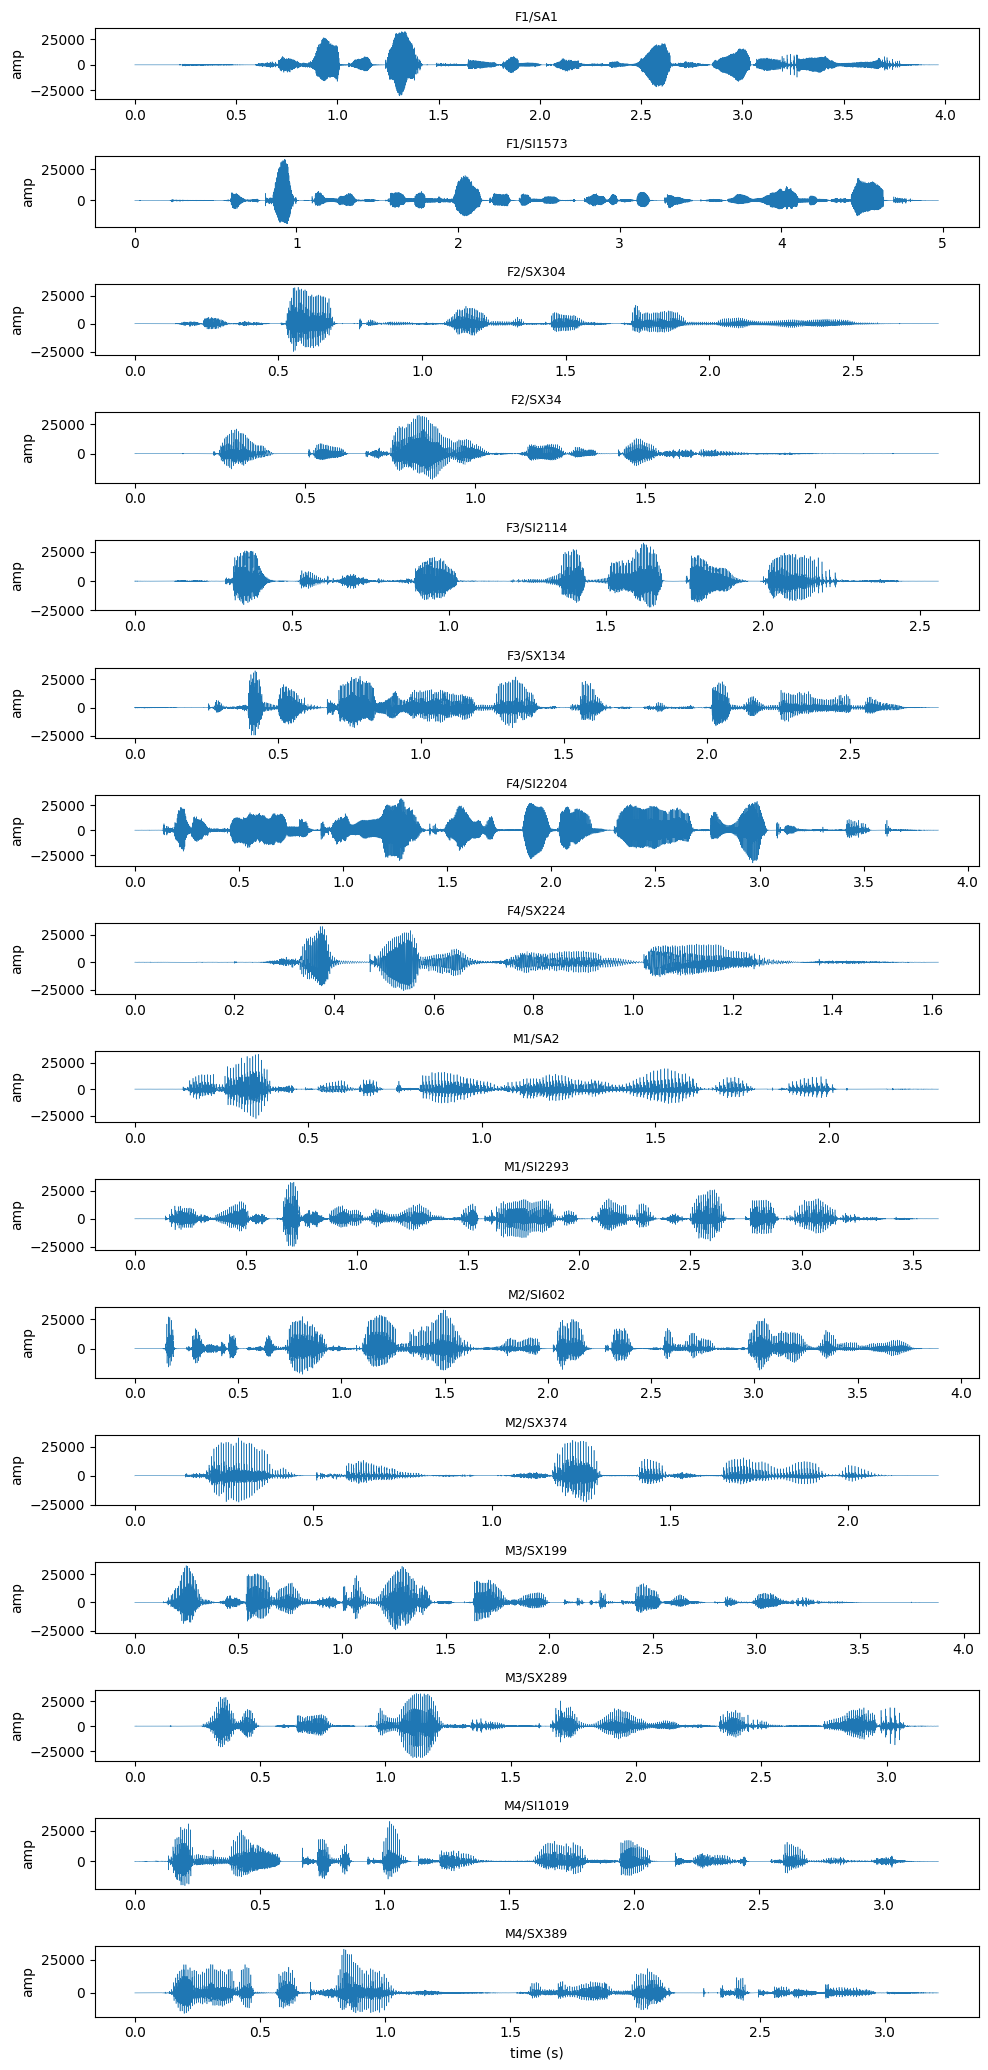

In [6]:
# Plot the signals
n = len(signals)
fig, axes = plt.subplots(n, 1, figsize=(10, 1.3*n))
for ax, (k, s) in zip(axes, signals.items()):
    t = np.arange(s["n_samples"]) / s["sr"]
    ax.plot(t, s["x"], lw=0.4)
    ax.set_title(k, fontsize=9); ax.set_ylabel("amp")
axes[-1].set_xlabel("time (s)")
plt.tight_layout()
plt.show()

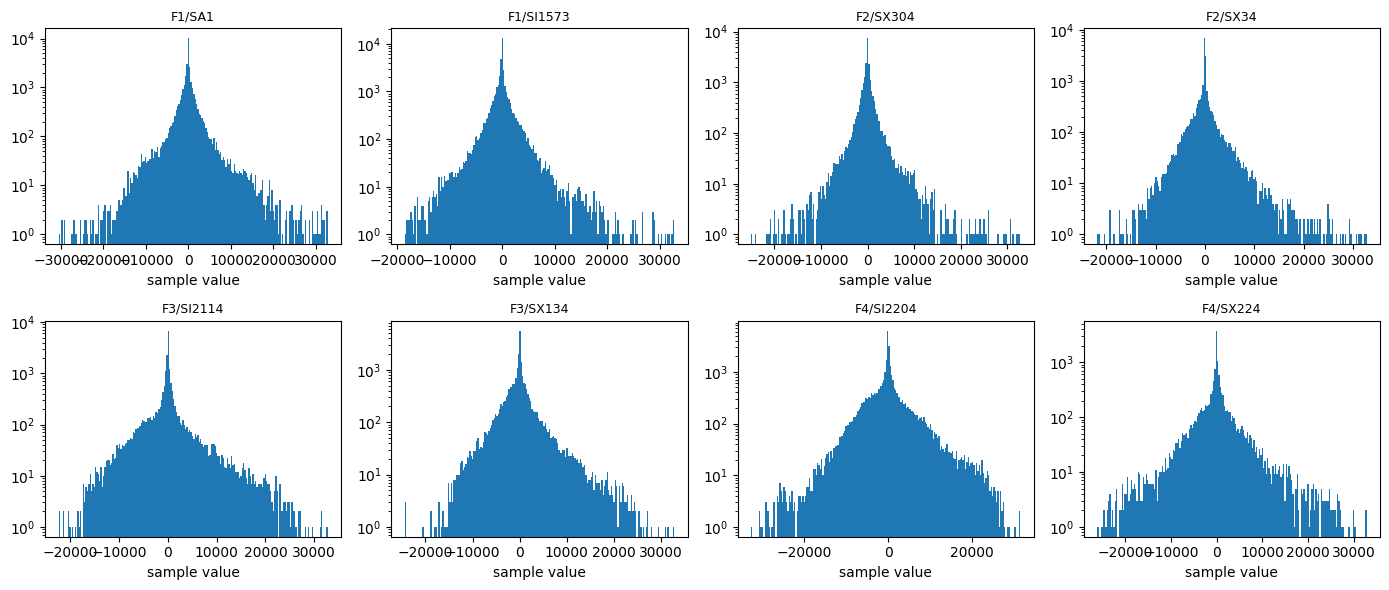

In [7]:
# Histograms of the sample values
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, (k, s) in zip(axes.flat, signals.items()):
    ax.hist(s["x"], bins=200, log=True)
    ax.set_title(k, fontsize=9); ax.set_xlabel("sample value")
plt.tight_layout()
plt.show()

In [8]:
# Compute the entropy of the sample values 
def entropy_bits(x):
    _, counts = np.unique(x, return_counts=True)
    p = counts / counts.sum()
    return -np.sum(p * np.log2(p))


# Summary table of the entropy
print(f"{'file':<14}{'H (bits/sample)':>18}{'dtype':>10}")
for k, s in signals.items():
    print(f"{k:<14}{entropy_bits(s['x']):>18.3f}{str(s['dtype']):>10}")

file             H (bits/sample)     dtype
F1/SA1                    11.957     int16
F1/SI1573                 11.664     int16
F2/SX304                  11.426     int16
F2/SX34                   10.923     int16
F3/SI2114                 11.720     int16
F3/SX134                  12.313     int16
F4/SI2204                 12.886     int16
F4/SX224                  11.856     int16
M1/SA2                    11.761     int16
M1/SI2293                 12.279     int16
M2/SI602                  12.146     int16
M2/SX374                  11.400     int16
M3/SX199                  11.651     int16
M3/SX289                  11.941     int16
M4/SI1019                 11.830     int16
M4/SX389                  11.636     int16


### Look at residual statistics

In [14]:
# Per-file residual statistics
rows = []
for key, s in signals.items():
    x = s["x"].astype(np.int32)
    r = np.diff(x, prepend=x[0])

    rows.append({
        "file":    key,
        "H_raw":   entropy_bits(x),
        "H_res":   entropy_bits(r),
        "std_x":   x.std(),
        "std_r":   r.std(),
        "corr":    np.corrcoef(x[:-1], x[1:])[0, 1],
        "uniq_x":  len(np.unique(x)),
        "uniq_r":  len(np.unique(r)),
    })

# Console table
hdr = (f"{'file':<14}{'H_raw':>8}{'H_res':>8}{'ΔH':>7}"
       f"{'std(x)':>9}{'std(r)':>9}{'corr':>7}{'|A_x|':>7}{'|A_r|':>7}")
print(hdr); print("-" * len(hdr))
for r in rows:
    dH = r["H_raw"] - r["H_res"]
    print(f"{r['file']:<14}{r['H_raw']:>8.3f}{r['H_res']:>8.3f}{dH:>7.3f}"
          f"{r['std_x']:>9.0f}{r['std_r']:>9.0f}{r['corr']:>7.3f}"
          f"{r['uniq_x']:>7}{r['uniq_r']:>7}")

# Summary line
mean_dH   = np.mean([r["H_raw"] - r["H_res"] for r in rows])
mean_corr = np.mean([r["corr"] for r in rows])
print(f"\nMean entropy reduction: {mean_dH:.3f} bits/sample")
print(f"Mean lag-1 correlation: {mean_corr:.3f}")

file             H_raw   H_res     ΔH   std(x)   std(r)   corr  |A_x|  |A_r|
----------------------------------------------------------------------------
F1/SA1          11.957  11.635  0.322     3352     2523  0.717   9069   7720
F1/SI1573       11.664  11.142  0.522     2456     1820  0.725   8832   6823
F2/SX304        11.426  10.823  0.603     2413     1818  0.716   6154   4791
F2/SX34         10.923  10.490  0.432     2879     1944  0.772   6315   4941
F3/SI2114       11.720  11.161  0.558     4186     3111  0.724   7774   6327
F3/SX134        12.313  11.707  0.606     3748     2802  0.721   8957   6817
F4/SI2204       12.886  12.338  0.547     5260     3235  0.811  13131   9977
F4/SX224        11.856  11.369  0.487     4682     2255  0.884   6460   5067
M1/SA2          11.761  11.161  0.600     3010     1838  0.814   7314   5437
M1/SI2293       12.279  11.669  0.610     3207     1925  0.820   9503   7175
M2/SI602        12.146  11.605  0.541     3068     2244  0.733   9085   7387

### Implementing mu-law quantization

file            dur(s)   |A_raw|   H_raw   |A_mu|    H_mu  SNR(dB)
------------------------------------------------------------------
F1/SA1            3.97      9069  11.957      254   7.533    37.93
F1/SI1573         4.97      8832  11.664      242   7.363    37.90
F2/SX304          2.80      6154  11.426      248   7.302    37.93
F2/SX34           2.36      6315  10.923      246   7.044    37.68
F3/SI2114         2.56      7774  11.720      247   7.530    37.86
F3/SX134          2.81      8957  12.313      244   7.680    37.74
F4/SI2204         3.86     13131  12.886      254   7.795    37.94
F4/SX224          1.61      6460  11.856      250   7.641    37.79
M1/SA2            2.32      7314  11.761      247   7.337    37.73
M1/SI2293         3.62      9503  12.279      248   7.567    37.67
M2/SI602          3.89      9085  12.146      245   7.563    37.90
M2/SX374          2.25      5941  11.400      247   7.374    37.90
M3/SX199          3.88      8587  11.651      248   7.385    3

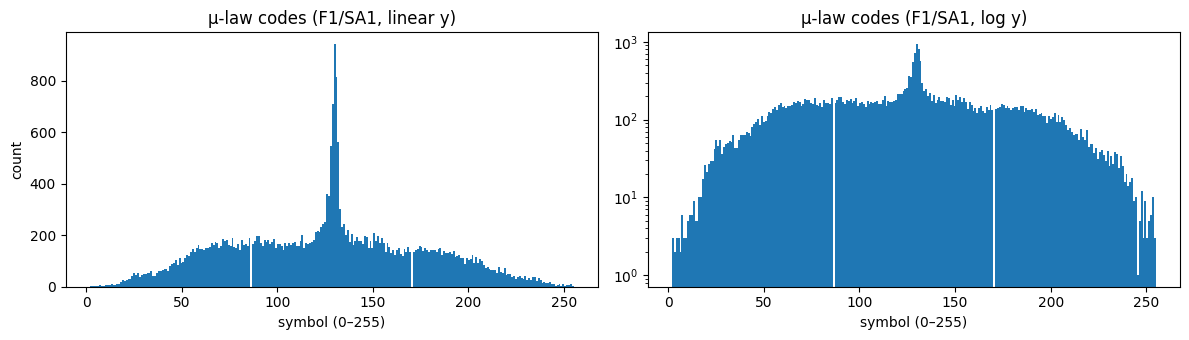

In [15]:
# Create functions for mu-law encoding and decoding
def mu_law_encode(x, mu=255, x_max=32768):
    x_norm = x.astype(np.float64) / x_max 
    y = np.sign(x_norm) * np.log1p(mu * np.abs(x_norm)) / np.log1p(mu)
    q = np.round((y + 1) / 2 * mu).astype(np.uint8)  # to {0, ..., 255}
    return q

def mu_law_decode(q, mu=255, x_max=32768):
    y = 2 * q.astype(np.float64) / mu - 1
    x = np.sign(y) * (np.expm1(np.abs(y) * np.log1p(mu))) / mu
    return (x * x_max).astype(np.int16)

def mu_law_snr(x):
    """Return reconstruction SNR (dB) for the μ-law round-trip on signal x."""
    x_rec = mu_law_decode(mu_law_encode(x))
    err   = x.astype(float) - x_rec.astype(float)
    return 10 * np.log10(np.sum(x.astype(float)**2) / np.sum(err**2))

# Per-file μ-law statistics
rows = []
for key, s in signals.items():
    x = s["x"]
    q = mu_law_encode(x)
    rows.append({
        "file":      key,
        "dur":       s["duration_s"],
        "alpha_raw": len(np.unique(x)),
        "H_raw":     entropy_bits(x),
        "alpha_mu":  len(np.unique(q)),
        "H_mu":      entropy_bits(q),
        "snr":       mu_law_snr(x),
    })

# Table
hdr = (f"{'file':<14}{'dur(s)':>8}{'|A_raw|':>10}{'H_raw':>8}"
       f"{'|A_mu|':>9}{'H_mu':>8}{'SNR(dB)':>9}")
print(hdr); print("-" * len(hdr))
for r in rows:
    print(f"{r['file']:<14}{r['dur']:>8.2f}{r['alpha_raw']:>10}"
          f"{r['H_raw']:>8.3f}{r['alpha_mu']:>9}{r['H_mu']:>8.3f}{r['snr']:>9.2f}")

# Pooled-stream entropy
all_q = np.concatenate([mu_law_encode(s["x"]) for s in signals.values()])
print(f"\nPooled stream: {len(all_q):,} symbols, "
      f"H_mu = {entropy_bits(all_q):.4f} bits/symbol")


# Histogram of μ-law codes for a single named file
example_key = "F1/SA1"
q_example   = mu_law_encode(signals[example_key]["x"])

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].hist(q_example, bins=256);          ax[0].set_title(f"μ-law codes ({example_key}, linear y)")
ax[1].hist(q_example, bins=256, log=True); ax[1].set_title(f"μ-law codes ({example_key}, log y)")
for a in ax:
    a.set_xlabel("symbol (0–255)")
ax[0].set_ylabel("count")
plt.tight_layout(); plt.show()

### Huffman Encoding

In [17]:
# Huffman three
def build_huffman_codes(symbols):
    """Return {symbol: bitstring} from an iterable of symbols."""
    # Heap entries: (count, tiebreaker_id, node)
    # node is either a leaf int (symbol) or a tuple (left_node, right_node)
    freq = Counter(symbols)
    tiebreak = 0
    heap = []
    for sym, c in freq.items():
        heapq.heappush(heap, (c, tiebreak, int(sym)))
        tiebreak += 1

    while len(heap) > 1:
        c1, _, n1 = heapq.heappop(heap)
        c2, _, n2 = heapq.heappop(heap)
        heapq.heappush(heap, (c1 + c2, tiebreak, (n1, n2)))
        tiebreak += 1

    root = heap[0][2]

    codes = {}
    def walk(node, prefix):
        if isinstance(node, tuple):
            walk(node[0], prefix + "0")
            walk(node[1], prefix + "1")
        else:
            codes[node] = prefix
    walk(root, "")
    return codes, freq


# Train on the pool of all 16 files (μ-law encoded)
all_codes = np.concatenate([mu_law_encode(s["x"]) for s in signals.values()])
print(f"Total μ-law symbols in training pool: {len(all_codes):,}")

codes, freq = build_huffman_codes(all_codes)
total = sum(freq.values())

# Compute the average code length, entropy, and code length range
avg_len = sum(freq[s] * len(codes[s]) for s in codes) / total
H = -sum((freq[s]/total) * np.log2(freq[s]/total) for s in codes)
max_len = max(len(c) for c in codes.values())
min_len = min(len(c) for c in codes.values())

print(f"alphabet size (table entries): {len(codes)}")
print(f"entropy H = {H:.4f} bits/symbol")
print(f"avg Huffman length L = {avg_len:.4f} bits/symbol")
print(f"redundancy L − H = {avg_len - H:.4f} bits/symbol")
print(f"code length range: {min_len} - {max_len} bits")
print(f"vs. fixed 8-bit μ-law: saving = {(1 - avg_len/8)*100:.2f} %")

Total μ-law symbols in training pool: 404,282
alphabet size (table entries): 256
entropy H = 7.5503 bits/symbol
avg Huffman length L = 7.5901 bits/symbol
redundancy L − H = 0.0398 bits/symbol
code length range: 5 - 16 bits
vs. fixed 8-bit μ-law: saving = 5.12 %


rank  symbol      count     prob  len codeword            
   1     130       9747   0.0241    5  01000               
   2     129       9695   0.0240    5  00111               
   3     131       9202   0.0228    5  00100               
   4     128       8248   0.0204    6  110110              
   5     132       6648   0.0164    6  100101              
   6     127       5314   0.0131    6  010111              
   7     126       4929   0.0122    6  010010              
   8     133       4602   0.0114    6  001010              
   9     125       3795   0.0094    7  1011100             
  10     135       3734   0.0092    7  1011001             
...
 252       2         15   0.0000   15  101101000101001     
 253       4         13   0.0000   15  101101000101000     
 254       3         12   0.0000   15  011101010010001     
 255       1          5   0.0000   16  0111010100100001    
 256       0          1   0.0000   16  0111010100100000    


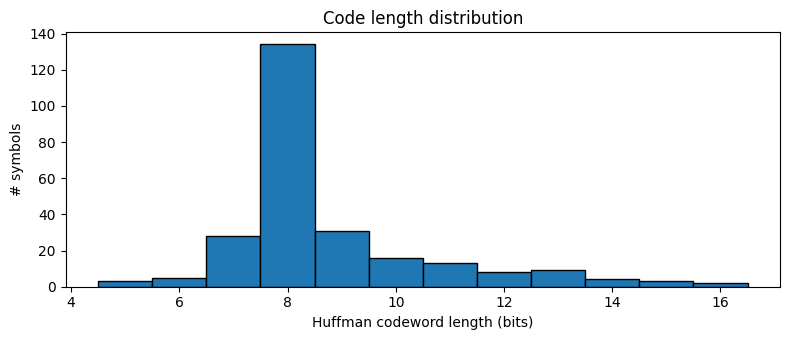

In [18]:
# Huffman table with code length per symbol, sorted by frequency
lengths_by_freq = sorted([(s, freq[s], len(codes[s])) for s in codes], key=lambda t: -t[1])

print(f"{'rank':>4} {'symbol':>7} {'count':>10} {'prob':>8} {'len':>4} {'codeword':<20}")
for rank, (s, c, L) in enumerate(lengths_by_freq[:10], 1):
    print(f"{rank:>4} {s:>7} {c:>10} {c/total:>8.4f} {L:>4}  {codes[s]:<20}")
print("...")
for rank, (s, c, L) in enumerate(lengths_by_freq[-5:], len(lengths_by_freq)-4):
    print(f"{rank:>4} {s:>7} {c:>10} {c/total:>8.4f} {L:>4}  {codes[s]:<20}")

# Distribution of code lengths 
ls = [len(codes[s]) for s in codes]
plt.figure(figsize=(8, 3.5))
plt.hist(ls, bins=range(min(ls), max(ls)+2), align="left", edgecolor="black")
plt.xlabel("Huffman codeword length (bits)"); plt.ylabel("# symbols")
plt.title("Code length distribution")
plt.tight_layout()
plt.savefig("huffman_code_length_distribution.png")
plt.show()

In [30]:
# Per-file bit rate using the trained table
print(f"{'file':<14}{'bits/sym':>10}{'kbps':>8}")
print("-" * 32)
for k, s in signals.items():
    q = mu_law_encode(s["x"])
    bits = sum(len(codes[c]) for c in q)
    bps  = bits / len(q)
    kbps = bps * s["sr"] / 1000
    print(f"{k:<14}{bps:>10.4f}{kbps:>8.2f}")
print(f"\nFor reference: μ-law fixed 8-bit = 64.00 kbps")

file            bits/sym    kbps
--------------------------------
F1/SA1            7.5861   60.69
F1/SI1573         7.4447   59.56
F2/SX304          7.4257   59.41
F2/SX34           7.1765   57.41
F3/SI2114         7.6133   60.91
F3/SX134          7.7848   62.28
F4/SI2204         8.0486   64.39
F4/SX224          7.8073   62.46
M1/SA2            7.4588   59.67
M1/SI2293         7.6596   61.28
M2/SI602          7.6617   61.29
M2/SX374          7.4889   59.91
M3/SX199          7.4813   59.85
M3/SX289          7.6515   61.21
M4/SI1019         7.5772   60.62
M4/SX389          7.5031   60.02

For reference: μ-law fixed 8-bit = 64.00 kbps


### Look at the effect of amount of training data

In [19]:
# Set random seed for reproducibility
random.seed(0)

# Hold out the "outlier" file F4/SI2204 plus two others as a fixed test set
test_keys  = ["F4/SI2204", "M1/SA2", "F2/SX34"]
train_keys = [k for k in signals if k not in test_keys]

# Create the training pool and test streams
train_pool = np.concatenate([mu_law_encode(signals[k]["x"]) for k in train_keys])
test_streams = {k: mu_law_encode(signals[k]["x"]) for k in test_keys}

# Function to compute the average bits/symbol for a test stream using a given code table
def code_with_table(stream, codes, fallback_bits=16):
    """Charge fallback_bits for any symbol missing from the trained table.
    16 bits ≈ an 8-bit escape flag + 8 bits of raw value, a conservative
    estimate of what a real coder would pay for an out-of-table symbol."""
    total = 0
    for s in stream:
        total += len(codes[s]) if s in codes else fallback_bits
    return total / len(stream)

# Learning curve: train on N symbols, test on held-out files
train_sizes = [1_000, 3_000, 10_000, 30_000, 100_000, len(train_pool)]
print(f"{'N_train':>10} {'alphabet':>9} " + " ".join(f"{k:>14}" for k in test_keys) + "  avg")
for N in train_sizes:
    subset = train_pool[:N]
    codes_N, _ = build_huffman_codes(subset)
    rates = [code_with_table(test_streams[k], codes_N) for k in test_keys]
    print(f"{N:>10} {len(codes_N):>9} " + " ".join(f"{r:>14.4f}" for r in rates)
          + f"  {np.mean(rates):.4f}")

   N_train  alphabet      F4/SI2204         M1/SA2        F2/SX34  avg
      1000        22        14.7768        13.1404        11.6565  13.1912
      3000        87        12.4835        11.3048         9.5699  11.1194
     10000       234         8.4073         7.6467         7.1603  7.7381
     30000       254         8.0811         7.4946         7.2623  7.6127
    100000       254         8.2232         7.5599         7.1892  7.6574
    335980       255         8.1101         7.5166         7.2207  7.6158


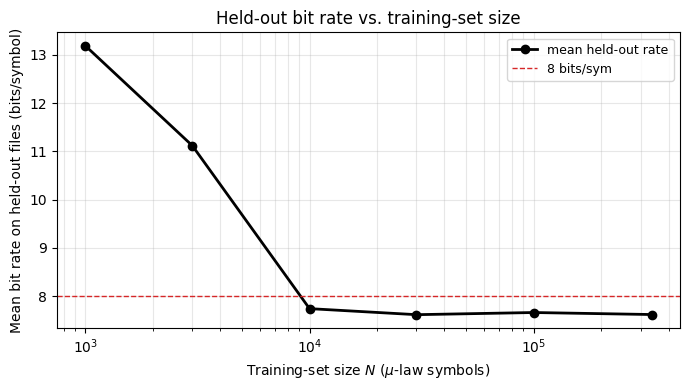

In [24]:
# Learning-curve figure 
N_values  = [1_000, 3_000, 10_000, 30_000, 100_000, 335_980]
mean_rate = [13.1912, 11.1194, 7.7381, 7.6127, 7.6574, 7.6158]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(N_values, mean_rate, marker="o", lw=2, color="k", label="mean held-out rate")
ax.axhline(8.0, ls="--", color="C3", lw=1, label="8 bits/sym")
ax.set_xscale("log")
ax.set_xlabel("Training-set size $N$ ($\\mu$-law symbols)")
ax.set_ylabel("Mean bit rate on held-out files (bits/symbol)")
ax.set_title("Held-out bit rate vs. training-set size")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig("training_curve.pdf", bbox_inches="tight")
plt.show()

### Now encode pairs of symbols

In [34]:
# Pack two uint8 symbols into one uint16 "super-symbol"
def make_pairs(stream):
    s = stream.astype(np.uint16)
    if len(s) % 2: s = s[:-1]
    return (s[0::2] << 8) | s[1::2]

# Build a Huffman code for the pairs and evaluate the average bits/symbol
pair_pool = make_pairs(all_codes)
pair_codes, pair_freq = build_huffman_codes(pair_pool)
pair_total = sum(pair_freq.values())
pair_avg_len = sum(pair_freq[s] * len(pair_codes[s]) for s in pair_codes) / pair_total
pair_H = -sum((pair_freq[s]/pair_total) * np.log2(pair_freq[s]/pair_total) for s in pair_codes)

print(f"Pair-coding (block size = 2):")
print(f" table entries (used) : {len(pair_codes):,}  (out of 65,536 possible)")
print(f" H (per pair) : {pair_H:.4f} bits")
print(f" L (per pair) : {pair_avg_len:.4f} bits")
print(f" per μ-law symbol : {pair_avg_len/2:.4f} bits, single-symbol was 7.5901")
print(f" kbps : {pair_avg_len/2 * 8000 / 1000:.2f}")
print(f" saving vs single-sym : {(1 - pair_avg_len/2/7.5901)*100:.2f} %")

Pair-coding (block size = 2):
 table entries (used) : 29,606  (out of 65,536 possible)
 H (per pair) : 13.5671 bits
 L (per pair) : 13.5972 bits
 per μ-law symbol : 6.7986 bits, single-symbol was 7.5901
 kbps : 54.39
 saving vs single-sym : 10.43 %


### Looking at the effect of errors

In [26]:
# Bit-error robustness statistics
def encode_stream(stream, codes):
    return "".join(codes[s] for s in stream)

def decode_bitstring(bits, codes):
    """Fast decoder using a prefix-trie built once per call."""
    inv  = {v: k for k, v in codes.items()}
    out  = []
    buf  = []
    for b in bits:
        buf.append(b)
        key = "".join(buf)
        if key in inv:
            out.append(inv[key])
            buf.clear()
    return np.array(out, dtype=np.uint8)

def flip_damage(bits, flip_pos, orig_dec, codes):
    """Flip one bit, decode, return (n_wrong, len_drift)."""
    b = bits[:flip_pos] + ("1" if bits[flip_pos] == "0" else "0") + bits[flip_pos+1:]
    dec = decode_bitstring(b, codes)
    L = min(len(orig_dec), len(dec))
    n_wrong   = int((orig_dec[:L] != dec[:L]).sum())
    len_drift = len(orig_dec) - len(dec)
    return n_wrong, len_drift

# Run the experiment on each file
rng = np.random.default_rng(0)
N_TRIALS = 200

rows = []
for key, s in signals.items():
    stream   = mu_law_encode(s["x"])
    bits     = encode_stream(stream, codes)
    orig_dec = decode_bitstring(bits, codes)

    # Flip positions confined to the first 80% so propagation has room
    positions = rng.integers(0, int(0.8 * len(bits)), size=N_TRIALS)

    n_bads  = np.empty(N_TRIALS, dtype=np.int64)
    drifts  = np.empty(N_TRIALS, dtype=np.int64)
    for i, p in enumerate(positions):
        n_bads[i], drifts[i] = flip_damage(bits, int(p), orig_dec, codes)

    rows.append({
        "file":      key,
        "n_sym":     len(orig_dec),
        "n_bits":    len(bits),
        "median":    int(np.median(n_bads)),
        "mean":      float(np.mean(n_bads)),
        "max":       int(np.max(n_bads)),
        "pct_le10":  100 * np.mean(n_bads <= 10),
        "pct_ge100": 100 * np.mean(n_bads >= 100),
        "mean_drift": float(np.mean(np.abs(drifts))),
    })

# Table
hdr = (f"{'file':<14}{'n_sym':>7}{'med':>5}{'mean':>9}{'max':>7}"
       f"{'%≤10':>7}{'%≥100':>7}{'|drift|':>9}")
print(hdr); print("-" * len(hdr))
for r in rows:
    print(f"{r['file']:<14}{r['n_sym']:>7}{r['median']:>5}"
          f"{r['mean']:>9.0f}{r['max']:>7}"
          f"{r['pct_le10']:>7.1f}{r['pct_ge100']:>7.1f}"
          f"{r['mean_drift']:>9.2f}")

# Pooled summary
all_bads = np.concatenate([
    [r["mean"]] for r in rows
])
print(f"\nAcross all {len(rows)} files, {N_TRIALS} flips each:")
print(f"  mean of per-file medians         : {np.mean([r['median'] for r in rows]):.1f}")
print(f"  mean of per-file means           : {np.mean([r['mean'] for r in rows]):.0f}")
print(f"  worst-case max (any file)        : {max(r['max'] for r in rows):,}")
print(f"  mean fraction re-syncing fast    : {np.mean([r['pct_le10'] for r in rows]):.1f}%")
print(f"  mean fraction cascading (≥100)   : {np.mean([r['pct_ge100'] for r in rows]):.1f}%")

file            n_sym  med     mean    max   %≤10  %≥100  |drift|
-----------------------------------------------------------------
F1/SA1          31744    6     8185  30539   53.5   42.5     0.76
F1/SI1573       39783    1     8096  37830   64.0   33.0     0.57
F2/SX304        22375    1     3923  21211   67.5   27.0     0.39
F2/SX34         18893    2     5242  17544   55.5   44.0     0.71
F3/SI2114       20480    6     4840  19246   52.0   43.5     0.81
F3/SX134        22477    2     5602  21001   58.5   40.0     0.66
F4/SI2204       30874    6     8497  30139   52.5   45.0     0.91
F4/SX224        12903   12     3711  12317   49.0   49.5     0.97
M1/SA2          18535    1     4008  17771   63.0   35.0     0.60
M1/SI2293       28928    1     5449  27999   65.0   30.0     0.49
M2/SI602        31130    1     5115  29943   69.0   27.0     0.49
M2/SX374        18023    4     4243  17119   56.0   39.5     0.66
M3/SX199        31028    4     7704  29405   56.5   40.0     0.63
M3/SX289  

File: F1/SA1   (31,744 symbols, 240,813 bits)
flips tested: 200
 median =      6.0
 mean =   8184.7
 max =    30539
 % ≤10 = 53.5
 % ≥100 = 42.5
 |drift| = 0.76


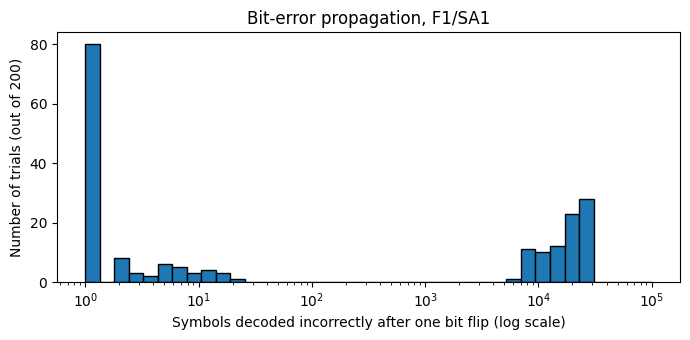

In [29]:
# Bit-error propagation: damage distribution for one representative file
example_key = "F1/SA1"
stream = mu_law_encode(signals[example_key]["x"])
bits = encode_stream(stream, codes)
orig = decode_bitstring(bits, codes)

def damage_from_flip(pos):
    b = bits[:pos] + ("1" if bits[pos] == "0" else "0") + bits[pos+1:]
    dec = decode_bitstring(b, codes)
    L = min(len(orig), len(dec))
    n_bad = int((orig[:L] != dec[:L]).sum())
    len_drift = len(orig) - len(dec)
    return n_bad, len_drift

rng = np.random.default_rng(0)
positions = rng.integers(0, int(0.8 * len(bits)), size=200)
results = [damage_from_flip(int(p)) for p in positions]
n_bads, drifts = map(np.array, zip(*results))

print(f"File: {example_key}   ({len(orig):,} symbols, {len(bits):,} bits)")
print(f"flips tested: {len(results)}")
print(f" median = {np.median(n_bads):8.1f}")
print(f" mean = {np.mean(n_bads):8.1f}")
print(f" max = {np.max(n_bads):8d}")
print(f" % ≤10 = {100*np.mean(n_bads <= 10):.1f}")
print(f" % ≥100 = {100*np.mean(n_bads >= 100):.1f}")
print(f" |drift| = {np.mean(np.abs(drifts)):.2f}")

# Plot on log-x so both lobes of the bimodal distribution are visible
plt.figure(figsize=(7, 3.5))
plt.hist(np.clip(n_bads, 1, None), bins=np.logspace(0, 5, 40), edgecolor="black")
plt.xscale("log")
plt.xlabel("Symbols decoded incorrectly after one bit flip (log scale)")
plt.ylabel("Number of trials (out of 200)")
plt.title(f"Bit-error propagation, {example_key}")
plt.tight_layout()
plt.savefig("biterror_histogram.pdf", bbox_inches="tight")
plt.show()